In [10]:
# The project was supposed to use real-time analysis on amazoon reviews using amazon review scrapper. However, I am postpone the comments scrapping due to the new policies and limitations of Amazon. In this regard, the dataset from Kaggle website is used to proceed the project.
from pathlib import Path
import sys
import nltk

sys.path.append("../src")

from sentimazon.data_loader import load_reviews, select_review_columns
from sentimazon.preprocessing import preprocess_reviews
from sentimazon.aspect_extraction import (
    add_pos_tags,
    add_nouns,
    get_noun_counts,
    get_filtered_noun_counts
)
from sentimazon.visualization import (
    plot_top_noun_keywords,
    plot_top_product_aspects
)

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

DATA_PATH = Path("../data/Mobile_Reviews_Sentiment.csv")

data = load_reviews(DATA_PATH)
data = select_review_columns(data)

data.head()

[nltk_data] Downloading package stopwords to C:\Users\V I S I O
[nltk_data]     N\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\V I S I O
[nltk_data]     N\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\V I S I O
[nltk_data]     N\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\V I S I O N\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


,review_text,sentiment
0,Not worth the money spent. Wouldn’t recommend.,Negative
1,Absolutely love this phone! The camera is next...,Positive
2,Loving the clean UI and fast updates. Loving i...,Positive
3,Build quality feels solid and durable. No regr...,Positive
4,Not bad for daily use but could be optimized. ...,Neutral


In [11]:
data = preprocess_reviews(data)
data

,review_text,sentiment,Cleancomment,applied stop_words,tokenized_Comments,lemmatized_Comments
0,Not worth the money spent. Wouldn’t recommend.,Negative,not worth the money spent wouldn t recommend,worth money spent recommend,"[worth, money, spent, recommend]","[worth, money, spent, recommend]"
1,Absolutely love this phone! The camera is next...,Positive,absolutely love this phone the camera is next...,absolutely love phone camera next level absolu...,"[absolutely, love, phone, camera, next, level,...","[absolutely, love, phone, camera, next, level,..."
2,Loving the clean UI and fast updates. Loving i...,Positive,loving the clean ui and fast updates loving i...,loving clean ui fast updates loving far,"[loving, clean, ui, fast, updates, loving, far]","[loving, clean, ui, fast, update, loving, far]"
3,Build quality feels solid and durable. No regr...,Positive,build quality feels solid and durable no regr...,build quality feels solid durable regrets buyi...,"[build, quality, feels, solid, durable, regret...","[build, quality, feel, solid, durable, regret,..."
4,Not bad for daily use but could be optimized. ...,Neutral,not bad for daily use but could be optimized ...,bad daily use could optimized average experien...,"[bad, daily, use, could, optimized, average, e...","[bad, daily, use, could, optimized, average, e..."
...,...,...,...,...,...,...
49995,Battery easily lasts a day with heavy use. Lov...,Positive,battery easily lasts a day with heavy use lov...,battery easily lasts day heavy use loving far,"[battery, easily, lasts, day, heavy, use, lovi...","[battery, easily, last, day, heavy, use, lovin..."
49996,Battery life could be slightly better. Fine bu...,Neutral,battery life could be slightly better fine bu...,battery life could slightly better fine could ...,"[battery, life, could, slightly, better, fine,...","[battery, life, could, slightly, better, fine,..."
49997,"Face unlock is instant, super smooth. Best pur...",Positive,face unlock is instant super smooth best pur...,face unlock instant super smooth best purchase...,"[face, unlock, instant, super, smooth, best, p...","[face, unlock, instant, super, smooth, best, p..."
49998,Build quality feels solid and durable. Loving ...,Positive,build quality feels solid and durable loving ...,build quality feels solid durable loving far,"[build, quality, feels, solid, durable, loving...","[build, quality, feel, solid, durable, loving,..."


In [12]:
data = add_pos_tags(data)
data = add_nouns(data)

data.head()

,review_text,sentiment,Cleancomment,applied stop_words,tokenized_Comments,lemmatized_Comments,pos_tags,nouns
0,Not worth the money spent. Wouldn’t recommend.,Negative,not worth the money spent wouldn t recommend,worth money spent recommend,"[worth, money, spent, recommend]","[worth, money, spent, recommend]","[(worth, JJ), (money, NN), (spent, VBN), (reco...","[money, recommend]"
1,Absolutely love this phone! The camera is next...,Positive,absolutely love this phone the camera is next...,absolutely love phone camera next level absolu...,"[absolutely, love, phone, camera, next, level,...","[absolutely, love, phone, camera, next, level,...","[(absolutely, RB), (love, VB), (phone, NN), (c...","[phone, camera, level]"
2,Loving the clean UI and fast updates. Loving i...,Positive,loving the clean ui and fast updates loving i...,loving clean ui fast updates loving far,"[loving, clean, ui, fast, updates, loving, far]","[loving, clean, ui, fast, update, loving, far]","[(loving, VBG), (clean, JJ), (ui, JJ), (fast, ...","[fast, update, loving]"
3,Build quality feels solid and durable. No regr...,Positive,build quality feels solid and durable no regr...,build quality feels solid durable regrets buyi...,"[build, quality, feels, solid, durable, regret...","[build, quality, feel, solid, durable, regret,...","[(build, JJ), (quality, NN), (feel, VBP), (sol...","[quality, buying]"
4,Not bad for daily use but could be optimized. ...,Neutral,not bad for daily use but could be optimized ...,bad daily use could optimized average experien...,"[bad, daily, use, could, optimized, average, e...","[bad, daily, use, could, optimized, average, e...","[(bad, JJ), (daily, JJ), (use, NN), (could, MD...","[use, experience]"


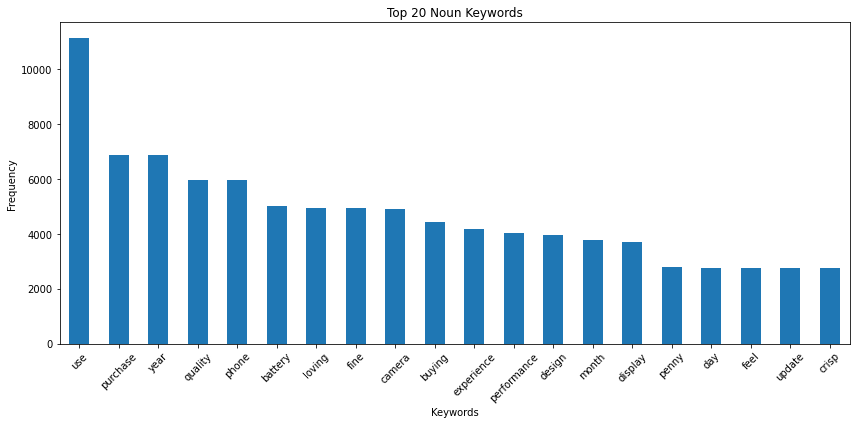

In [13]:
noun_counts = get_noun_counts(data)
plot_top_noun_keywords(noun_counts)

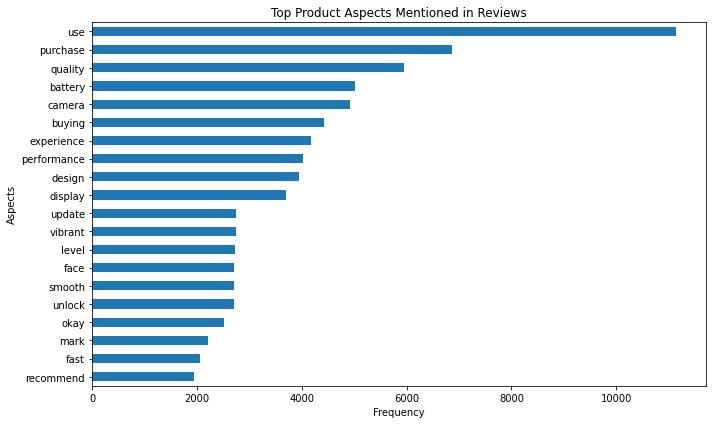

In [14]:
filtered_noun_counts = get_filtered_noun_counts(data)
plot_top_product_aspects(filtered_noun_counts)

In [20]:
import time

start_vader = time.time() 
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer 
vader_sentiment = []  
vader_sentiment_neg = [] 
vader_sentiment_pos = []
sid = SentimentIntensityAnalyzer()
for sentence in phrasesDF['review_text']:
    try:
        vader_sentiment.append(sid.polarity_scores(sentence)['compound'])
        vader_sentiment_pos.append(sid.polarity_scores(sentence)['pos'])
        vader_sentiment_neg.append(sid.polarity_scores(sentence)['neg'])
    except:
        vader_sentiment.append(0.5)
phrasesDF['vader_sentiment'] = pd.Series(vader_sentiment)   
phrasesDF['vader_sentiment_neg'] = pd.Series(vader_sentiment_neg)   
phrasesDF['vader_sentiment_pos'] = pd.Series(vader_sentiment_pos)


end_vader = time.time() 
vader_time = end_vader - start_vader 
print(f"VADER total runtime: {vader_time:.4f} seconds")  
print(f"VADER time per sample: {vader_time/len(phrasesDF):.6f} seconds")  


VADER total runtime: 19.4603 seconds
VADER time per sample: 0.001192 seconds


In [21]:
phrasesDF['vader_label'] = phrasesDF['vader_sentiment'].apply(
    lambda x: 'positive' if x >= 0.05 else ('negative' if x <= -0.05 else 'neutral')
)
phrasesDF

,review_text,sentiment,aspect,vader_sentiment,vader_sentiment_neg,vader_sentiment_pos,vader_label
0,Build quality feels solid and durable. No regr...,Positive,quality,-0.4767,0.329,0.112,negative
1,Battery easily lasts a day with heavy use. No ...,Positive,battery,-0.3182,0.292,0.149,negative
2,Battery easily lasts a day with heavy use. Lov...,Positive,battery,0.7644,0.000,0.423,positive
3,Smooth performance even after months of use. N...,Positive,performance,-0.5719,0.320,0.000,negative
4,Battery easily lasts a day with heavy use. No ...,Positive,battery,-0.3182,0.292,0.149,negative
...,...,...,...,...,...,...,...
16315,Battery life could be slightly better. Okay fo...,Neutral,battery,0.6160,0.000,0.463,positive
16316,Speaker quality is bad and muffled. Wouldn’t r...,Negative,quality,-0.2500,0.292,0.208,negative
16317,Battery easily lasts a day with heavy use. Lov...,Positive,battery,0.7644,0.000,0.423,positive
16318,Battery life could be slightly better. Fine bu...,Neutral,battery,0.6678,0.000,0.447,positive


In [22]:
from transformers import pipeline
start_trans = time.time()
sentiment_model = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english")
DistilBERT_transformer_sentiment = []
DistilBERT_transformer_sentiment_neg = []
DistilBERT_transformer_sentiment_pos = []
for sentence in phrasesDF['review_text']:
    try:
        result = sentiment_model(sentence)[0]
        if result['label'] == 'POSITIVE':
            DistilBERT_transformer_sentiment_pos.append(result['score'])
            DistilBERT_transformer_sentiment_neg.append(1 - result['score'])
            DistilBERT_transformer_sentiment.append(result['score'])
        else:
            DistilBERT_transformer_sentiment_neg.append(result['score'])
            DistilBERT_transformer_sentiment_pos.append(1 - result['score'])
            DistilBERT_transformer_sentiment.append(-result['score'])
    except:
        DistilBERT_transformer_sentiment.append(0.0)
        DistilBERT_transformer_sentiment_neg.append(0.0)
        DistilBERT_transformer_sentiment_pos.append(0.0)
phrasesDF['DistilBERT_transformer_sentiment'] = pd.Series(DistilBERT_transformer_sentiment)
phrasesDF['DistilBERT_transformer_sentiment_neg'] = pd.Series(DistilBERT_transformer_sentiment_neg)
phrasesDF['DistilBERT_transformer_sentiment_pos'] = pd.Series(DistilBERT_transformer_sentiment_pos)
end_trans = time.time()
trans_time = end_trans - start_trans
print(f"Transformer total runtime: {trans_time:.4f} seconds")
print(f"Transformer time per sample: {trans_time/len(phrasesDF):.6f} seconds") 

Transformer total runtime: 1539.3888 seconds
Transformer time per sample: 0.094325 seconds


In [23]:
phrasesDF['DistilBERT_transformer_sentiment'] = phrasesDF.apply(
    lambda row:
        'positive' if row['DistilBERT_transformer_sentiment_pos'] > row['DistilBERT_transformer_sentiment_neg']
        else 'negative',
    axis=1
)
phrasesDF = phrasesDF.drop(
    columns=['vader_sentiment_neg', 'vader_sentiment_pos'],
    errors='ignore'
)
phrasesDF

,review_text,sentiment,aspect,vader_sentiment,vader_label,DistilBERT_transformer_sentiment,DistilBERT_transformer_sentiment_neg,DistilBERT_transformer_sentiment_pos
0,Build quality feels solid and durable. No regr...,Positive,quality,-0.4767,negative,positive,0.000145,0.999855
1,Battery easily lasts a day with heavy use. No ...,Positive,battery,-0.3182,negative,negative,0.964003,0.035997
2,Battery easily lasts a day with heavy use. Lov...,Positive,battery,0.7644,positive,positive,0.000679,0.999321
3,Smooth performance even after months of use. N...,Positive,performance,-0.5719,negative,positive,0.001982,0.998018
4,Battery easily lasts a day with heavy use. No ...,Positive,battery,-0.3182,negative,negative,0.964003,0.035997
...,...,...,...,...,...,...,...,...
16315,Battery life could be slightly better. Okay fo...,Neutral,battery,0.6160,positive,negative,0.961484,0.038516
16316,Speaker quality is bad and muffled. Wouldn’t r...,Negative,quality,-0.2500,negative,negative,0.999617,0.000383
16317,Battery easily lasts a day with heavy use. Lov...,Positive,battery,0.7644,positive,positive,0.000679,0.999321
16318,Battery life could be slightly better. Fine bu...,Neutral,battery,0.6678,positive,negative,0.993408,0.006592


In [24]:
from transformers import pipeline
import time
import pandas as pd

start_trans = time.time()

roberta_model = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest"
)
RoBERTa_transformer_sentiment = []
RoBERTa_transformer_sentiment_neg = []
RoBERTa_transformer_sentiment_pos = []
for sentence in phrasesDF['review_text']:
    try:
        result = roberta_model(sentence)[0]
        label = result['label']
        score = result['score']
        if label == 'LABEL_2': 
            RoBERTa_transformer_sentiment_pos.append(score)
            RoBERTa_transformer_sentiment_neg.append(1 - score)
            RoBERTa_transformer_sentiment.append(score)
        else:  
            RoBERTa_transformer_sentiment_neg.append(score)
            RoBERTa_transformer_sentiment_pos.append(1 - score)
            RoBERTa_transformer_sentiment.append(-score)
    except:
        RoBERTa_transformer_sentiment.append(0.0)
        RoBERTa_transformer_sentiment_neg.append(0.0)
        RoBERTa_transformer_sentiment_pos.append(0.0)
phrasesDF['RoBERTa_transformer_sentiment'] = pd.Series(RoBERTa_transformer_sentiment)
phrasesDF['RoBERTa_transformer_sentiment_neg'] = pd.Series(RoBERTa_transformer_sentiment_neg)
phrasesDF['RoBERTa_transformer_sentiment_pos'] = pd.Series(RoBERTa_transformer_sentiment_pos)
end_trans = time.time()
trans_time = end_trans - start_trans
print(f"RoBERTa total runtime: {trans_time:.4f} seconds")
print(f"RoBERTa time per sample: {trans_time/len(phrasesDF):.6f} seconds")

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


RoBERTa total runtime: 2132.9343 seconds
RoBERTa time per sample: 0.130695 seconds


In [25]:
phrasesDF['RoBERTa_transformer_sentiment'] = phrasesDF.apply(
    lambda row:
        'positive' if row['RoBERTa_transformer_sentiment_pos'] > row['RoBERTa_transformer_sentiment_neg']
        else 'negative',
    axis=1
)

phrasesDF = phrasesDF.drop(
    columns=[
        'RoBERTa_transformer_sentiment_pos',
        'RoBERTa_transformer_sentiment_neg'
    ],
    errors='ignore'
)

phrasesDF

,review_text,sentiment,aspect,vader_sentiment,vader_label,DistilBERT_transformer_sentiment,DistilBERT_transformer_sentiment_neg,DistilBERT_transformer_sentiment_pos,RoBERTa_transformer_sentiment
0,Build quality feels solid and durable. No regr...,Positive,quality,-0.4767,negative,positive,0.000145,0.999855,negative
1,Battery easily lasts a day with heavy use. No ...,Positive,battery,-0.3182,negative,negative,0.964003,0.035997,negative
2,Battery easily lasts a day with heavy use. Lov...,Positive,battery,0.7644,positive,positive,0.000679,0.999321,negative
3,Smooth performance even after months of use. N...,Positive,performance,-0.5719,negative,positive,0.001982,0.998018,negative
4,Battery easily lasts a day with heavy use. No ...,Positive,battery,-0.3182,negative,negative,0.964003,0.035997,negative
...,...,...,...,...,...,...,...,...,...
16315,Battery life could be slightly better. Okay fo...,Neutral,battery,0.6160,positive,negative,0.961484,0.038516,negative
16316,Speaker quality is bad and muffled. Wouldn’t r...,Negative,quality,-0.2500,negative,negative,0.999617,0.000383,negative
16317,Battery easily lasts a day with heavy use. Lov...,Positive,battery,0.7644,positive,positive,0.000679,0.999321,negative
16318,Battery life could be slightly better. Fine bu...,Neutral,battery,0.6678,positive,negative,0.993408,0.006592,negative


In [26]:
phrasesDF['sentiment'] = phrasesDF['sentiment'].str.strip().str.capitalize()
phrasesDF['vader_label'] = phrasesDF['vader_label'].str.strip().str.capitalize()
phrasesDF['DistilBERT_transformer_sentiment'] = (
    phrasesDF['DistilBERT_transformer_sentiment']
    .str.strip()
    .str.capitalize()
)
phrasesDF['RoBERTa_transformer_sentiment'] = (
    phrasesDF['RoBERTa_transformer_sentiment']
    .str.strip()
    .str.capitalize()
)
phrasesDF['RoBERTa_transformer_sentiment'] = (
    phrasesDF['RoBERTa_transformer_sentiment']
    .replace('Neutral', 'Negative')
)

In [27]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import pandas as pd

def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average='weighted',
        zero_division=0
    )
    return acc, precision, recall, f1
v_acc, v_prec, v_rec, v_f1 = compute_metrics(
    phrasesDF['sentiment'],
    phrasesDF['vader_label']
)
d_acc, d_prec, d_rec, d_f1 = compute_metrics(
    phrasesDF['sentiment'],
    phrasesDF['DistilBERT_transformer_sentiment']
)
r_acc, r_prec, r_rec, r_f1 = compute_metrics(
    phrasesDF['sentiment'],
    phrasesDF['RoBERTa_transformer_sentiment']
)
results_table = pd.DataFrame({
    'Model': ['VADER', 'DistilBERT', 'RoBERTa'],
    'Accuracy': [v_acc, d_acc, r_acc],
    'Precision': [v_prec, d_prec, r_prec],
    'Recall': [v_rec, d_rec, r_rec],
    'F1-score': [v_f1, d_f1, r_f1]
})
results_table = results_table.round(4)
print("\n===== MODEL PERFORMANCE =====")
print(results_table)


===== MODEL PERFORMANCE =====
        Model  Accuracy  Precision  Recall  F1-score
0       VADER    0.5450     0.5271  0.5450    0.4824
1  DistilBERT    0.6434     0.4655  0.6434    0.5334
2     RoBERTa    0.1772     0.0331  0.1772    0.0558


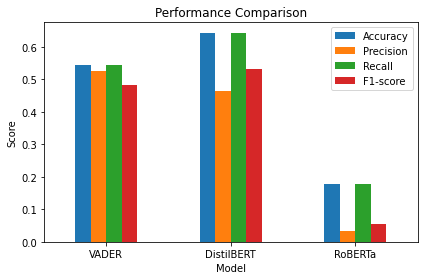

In [28]:
import matplotlib.pyplot as plt

results_table.set_index('Model').plot(kind='bar')
plt.title("Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()